# Simulation de diffusion sur un anneau

Ce notebook simule un processus de diffusion direct et inverse sur une distribution en anneau en 2D. 
Nous traçons l'évolution de la densité de probabilité ainsi que la dynamique de \(X\) dans les deux sens (forward et reverse).

Les méthodes numériques utilisées s'appuient sur l'intégration par Euler–Maruyama pour résoudre les SDEs.

**Références**:
- Euler–Maruyama: Kloeden & Platen, *Numerical Solution of Stochastic Differential Equations*, 1992.
- Diffusion Models: Song et al., *Score-Based Generative Modeling through Stochastic Differential Equations*, 2021.
- Distance de Fréchet Inceptron : Heusel, M., Ramsauer, H., Unterthiner, T., Nessler, B., & Hochreiter, S. (2017). *GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium*. (pour la définition et l'utilisation de la FID).


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from tqdm import tqdm


Génération de l'anneau

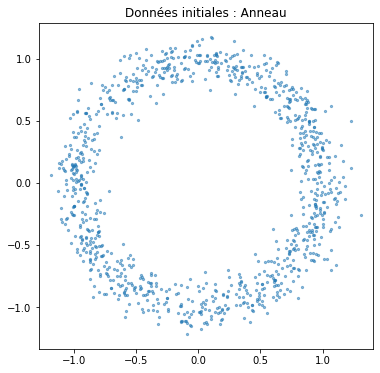

In [3]:
# Génération de données en anneau
n_samples = 1000
angles = 2 * np.pi * np.random.rand(n_samples)
radii = 1.0 + 0.1 * np.random.randn(n_samples)  # rayon autour de 1
x0_np = np.vstack((radii * np.cos(angles), radii * np.sin(angles))).T
x0 = torch.tensor(x0_np, dtype=torch.float)

plt.figure(figsize=(6,6))
plt.scatter(x0_np[:, 0], x0_np[:, 1], s=5, alpha=0.5)
plt.title('Données initiales : Anneau')
plt.axis('equal')
plt.show()

# Fonctions utiles

In [22]:
def forward_process_evolution(x0, beta, T, steps, snapshot_interval):
    """
    Simule le processus direct :
      dX_t = -beta * X_t dt + sqrt(2*beta*dt)*dW_t
    et enregistre périodiquement l'état de la distribution.
    
    Référence : Code inspiré de [Song et al., 2021] et [Ho et al., 2020].
    """
    dt = torch.tensor(T / steps)
    x = x0.clone()
    snapshots = []
    snapshots.append(x.detach().numpy().copy())
    #w = torch.zeros_like(x)
    for t in range(steps):
        noise = torch.randn_like(x)
        #dW = noise - w
        #w = noise
        x = x - beta * x * dt + torch.sqrt(2 * beta * dt) * noise #dW
        if (t+1) % snapshot_interval == 0:
            snapshots.append(x.detach().numpy().copy())
    return x, snapshots

def reverse_process_evolution(xT, score_model, beta, T, steps, snapshot_interval):
    """
    Simule le processus inverse :
      dX_t = beta*(score(x,t) - X_t) dt + sqrt(2*beta*dt)*dW_t
    et enregistre périodiquement l'état de la distribution.
    
    score(x,t) est estimé par score_model.
    
    Référence : Inspiré de [Song et al., 2021] et d'implémentations open-source de modèles de diffusion.
    """
    dt = torch.tensor(T / steps)
    x = xT.clone()
    snapshots = []
    snapshots.append(x.detach().numpy().copy())
    #w = torch.zeros_like(x)
    for t in reversed(range(steps)):
        noise = torch.randn_like(x) 
        #dW = noise - w # w_(t_k +1) - w_(t_k) Weiner process
        score = score_model(x)
        # La drift inverse est approximée par la contribution du score
        x = x + beta * (score - x) * dt + torch.sqrt(2 * beta * dt) * noise #dW
        if (t+1) % snapshot_interval == 0:
            snapshots.append(x.detach().numpy().copy())
        #w = dW
    return x, snapshots

In [21]:
from scipy.linalg import sqrtm

def calculate_fid(real_samples, generated_samples):
    """
    Calcule le Fréchet Inception Distance (FID) entre deux ensembles d'échantillons.
    
    Paramètres:
        real_samples (ndarray): Échantillons de la distribution réelle, de taille (N, d).
        generated_samples (ndarray): Échantillons de la distribution générée, de taille (N, d).
    
    Retourne:
        fid (float): La distance FID.
    """
    # Calcul des moyennes
    mu_r = np.mean(real_samples, axis=0)
    mu_g = np.mean(generated_samples, axis=0)
    
    # Calcul des matrices de covariance
    cov_r = np.cov(real_samples, rowvar=False)
    cov_g = np.cov(generated_samples, rowvar=False)
    
    # Calcul de la distance entre moyennes
    diff = mu_r - mu_g
    diff_sq = np.sum(diff ** 2)
    
    # Calcul de la racine carrée du produit des covariances
    covmean = sqrtm(cov_r@cov_g)
    # S'assurer que le résultat est réel
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # Calcul du FID
    fid = diff_sq + np.trace(cov_r + cov_g - 2 * covmean)
    return fid

# Réseau MLP

In [41]:
# Définition d'un réseau de neurones pour estimer le score (grad log p)
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)



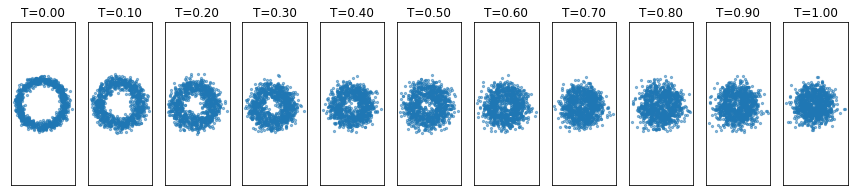

In [38]:
# Simulation du forward process
beta = 0.1
T = 1.0
steps = 1000
snapshot_interval = 100

xT, forward_snapshots = forward_process_evolution(x0, beta, T, steps, snapshot_interval)

# Visualisation de l'évolution du forward process
plt.figure(figsize=(15, 3))
for i, snap in enumerate(forward_snapshots):
    plt.subplot(1, len(forward_snapshots), i+1)
    plt.scatter(snap[:, 0], snap[:, 1], s=5, alpha=0.5)
    plt.title(f'T={i*snapshot_interval*T/steps:.2f}')
    plt.axis('equal')
    plt.xticks([])
    plt.yticks([])
plt.savefig('forward_process.png')

In [42]:
# Instanciation du modèle de score
score_model = ScoreNet()
optimizer = torch.optim.Adam(score_model.parameters(), lr=1e-3)


# Entraînement du réseau de score via score matching
# On ajoute du bruit aux échantillons et on apprend à prédire le bruit ajouté
noise_level = 0.1
n_epochs = 1000

for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    noise = torch.randn_like(x0)
    noisy_x = x0 + noise_level * noise
    target = -noise / noise_level
    loss = ((score_model(noisy_x) - target) ** 2).mean()
    loss.backward()
    optimizer.step()
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

 24%|██▍       | 245/1000 [00:00<00:02, 294.49it/s]

Epoch 200/1000, Loss: 85.3842


 43%|████▎     | 434/1000 [00:01<00:01, 308.96it/s]

Epoch 400/1000, Loss: 77.7780


...

Epoch 600/1000, Loss: 74.6229


 84%|████████▎ | 837/1000 [00:02<00:00, 366.50it/s]

Epoch 800/1000, Loss: 73.1402


100%|██████████| 1000/1000 [00:03<00:00, 306.27it/s]

Epoch 1000/1000, Loss: 72.9349


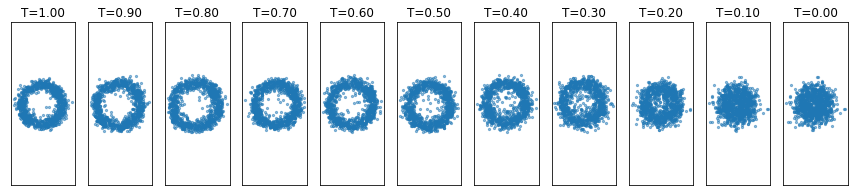

In [43]:
# Simulation du reverse process
x_gen, reverse_snapshots = reverse_process_evolution(xT, score_model, beta, T, steps, snapshot_interval)

# Inverser l'ordre d'affichage pour passer de t=0 à t=T
reverse_snapshots_inversed = reverse_snapshots[::-1]

# Visualisation de l'évolution du reverse process
plt.figure(figsize=(15, 3))
for i, snap in enumerate(reverse_snapshots_inversed):
    plt.subplot(1, len(reverse_snapshots_inversed), i+1)
    plt.scatter(snap[:, 0], snap[:, 1], s=5, alpha=0.5)
    plt.title(f'T={T - i * snapshot_interval * T/steps:.2f}')
    plt.axis('equal')
    plt.xticks([])
    plt.yticks([])
plt.savefig('reverse_process.png')

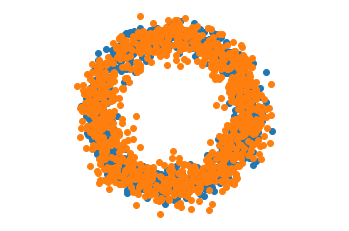

In [35]:
plt.plot(x0_np[:, 0], x0_np[:, 1], 'o', label='Données initiales')
plt.plot(x_gen.detach().numpy()[:, 0], x_gen.detach().numpy()[:, 1], 'o', label='Données générées')
plt.xticks([])
plt.yticks([])
plt.axis('equal')
# Suppression des cadres
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.savefig('generated_data.png')

Après enregistrement des anneaux réels et générés, on calcule la FID pour mesurer la qualité de génération.

In [29]:
# Calcul du FID entre la distribution réelle (anneau initial) et la distribution générée
# Pour cet exemple, on utilise 'x0' comme distribution réelle et 'x_gen' issue du processus inverse.
fid_value = calculate_fid(x0.detach().cpu().numpy(), x_gen.detach().cpu().numpy())
print("FID:", fid_value)

FID: 0.0003338253971636451
